### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 
from pulse_optimization import * 


In [2]:
from dataclasses import dataclass
import itertools
from pathlib import Path
from typing import Sequence
import numpy as np
import sympy as sp


@dataclass(frozen=True)
class PulseFitParams:
  A_r: sp.Expr
  A_i: sp.Expr
  dwd: sp.Expr
  wd0: float


def load_fit_params(
    tg: float,
    sigma_ratio: float,
    pulse_type: str = "gauss",
    fit_dir: str | Path = "operational_res/fit_data",
) -> PulseFitParams:
  file_path = (
      Path(fit_dir)
      / f"fit_params_{pulse_type}_tg_{round(tg)}ns_sigma_{sigma_ratio:.1f}.npz"
  )
  if not file_path.is_file():
    raise FileNotFoundError(f"Keine Fit-Datei unter '{file_path}' gefunden.")

  with np.load(file_path) as data:
    return PulseFitParams(
        A_r=sp.sympify(str(data["A_r_expr"])),
        A_i=sp.sympify(str(data["A_i_expr"])),
        dwd=sp.sympify(str(data["dwd_expr"])),
        wd0=float(data["wd0"]),
    )


def _substitute_time_symbol(expr: sp.Expr, target_t: sp.Symbol) -> sp.Expr:
  free_syms = expr.free_symbols
  if not free_syms:
    return expr
  t_candidate = next((s for s in free_syms if s.name == "t"), next(iter(free_syms)))
  return expr.subs(t_candidate, target_t)

def fitted_pulse(
    t_sym: sp.Symbol,
    coeffs: dict[str, sp.Symbol | float] | tuple | list,
    tg: float,
    sigma_ratio: float,
    pulse_type: str = "gauss",
    fit_dir: str | Path = "operational_res/fit_data",
    **kwargs,  # Fängt unbenutzte Kwargs (max_order, whitelist etc.) ab
) -> tuple[sp.Expr, sp.Expr]:
  """Erstellt A_expr (c_amp skaliert nur A_r) und wd_expr (c_dwd_offset als Frequenz-Shift)."""
  raw = load_fit_params(
      tg=tg, sigma_ratio=sigma_ratio, pulse_type=pulse_type, fit_dir=fit_dir
  )

  A_r = _substitute_time_symbol(raw.A_r, t_sym)
  A_i = _substitute_time_symbol(raw.A_i, t_sym)
  dwd = _substitute_time_symbol(raw.dwd, t_sym)

  # Zuordnung falls coeffs als List/Tuple übergeben wird: (c_amp, c_dwd_offset)
  if isinstance(coeffs, (tuple, list)):
    coeffs_dict = {
        "c_amp": coeffs[0] if len(coeffs) > 0 else 1.0,
        "c_dwd_offset": coeffs[1] if len(coeffs) > 1 else 0.0,
    }
  elif isinstance(coeffs, dict):
    coeffs_dict = coeffs
  else:
    coeffs_dict = {}

  c_amp = coeffs_dict.get("c_amp", 1.0)
  c_dwd_offset = coeffs_dict.get("c_dwd_offset", 0.0)

  # c_amp skaliert ausschließlich A_r, A_i bleibt unverändert
  A_expr = (c_amp * A_r) + sp.I * A_i
  wd_expr = raw.wd0 + dwd + c_dwd_offset

  return A_expr, wd_expr

# Optimization use

In [3]:
s = Simulation()
rH = 2
rW = 1
tg, sigma_ratio = 250.0, 0.3
pulse = "gauss"

# Parametergrenzen für c_amp und c_dwd_offset holen
param_ranges = {
      "c_amp": (0.8, 1.2),
      "c_dwd_offset": (-0.01,0.01),
}

# 1. Einmalige symbolische Vorberechnung von H_func und M_func
H_func, M_func = prepare_floquet_functions(
    pulse_shape_builder=lambda t, p: fitted_pulse(t, p, tg=tg, sigma_ratio=sigma_ratio, pulse_type = pulse),
    p_names=list(param_ranges.keys()),
    s=s,
    rH=rH,
    rW=rW,
    include_geometric=True,
    include_micromotion=True,
    include_g_correction=True,
    verbose=False,
)

KeyboardInterrupt: 

In [ ]:
# --- Setup für extrem schnelle Konvergenz (2 Parameter) ---
best_p, best_infid, best_psi_t, tlist = optimize_pulse_parameters(
    H_func=H_func,
    M_func=M_func,
    param_ranges=param_ranges,
    s=s,
    tg=tg,
    N_t=100,
    target_metric="population",
    verbose=True,
    # Tuning für 2D-Parameterraum:
    popsize=4,  # Bei 2 Parametern reichen 4-6 Individuen pro Generation
    maxiter=15,  # Konvergiert in 2D extrem schnell
    tol=1e-8,
    mutation=(0.2, 0.6),
    recombination=0.9,
    polish=True,  # L-BFGS-B findet das exakte Minimum am Ende im 2D-Raum in Millisekunden
    workers=1,
)

[DEBUG] Starte Puls-Optimierung
[DEBUG] Parameter (2): ['c_amp', 'c_dwd_offset']
[DEBUG] Hilbertraum D=27, Reduzierter Raum d_res=3, N_t=100
[DEBUG] Popsize=4 -> 8 Evall. pro Generation | Maxiter=15 | Workers=1
[DEBUG] Starte differential_evolution...
differential_evolution step 1: f(x)= 0.0075130322927302595
[DEBUG Gen Callback] Aufrufe:     16 | Bisher beste Infidelity: 7.513032e-03 | Conv: 8.6930e-09 | Zeit: 1.97s
differential_evolution step 2: f(x)= 0.0028190210146076256
[DEBUG Gen Callback] Aufrufe:     24 | Bisher beste Infidelity: 2.819021e-03 | Conv: 1.2763e-08 | Zeit: 2.94s
differential_evolution step 3: f(x)= 0.0026673785742951095
[DEBUG Gen Callback] Aufrufe:     32 | Bisher beste Infidelity: 2.667379e-03 | Conv: 2.0427e-08 | Zeit: 3.91s
differential_evolution step 4: f(x)= 0.0018524552155573248
[DEBUG Gen Callback] Aufrufe:     40 | Bisher beste Infidelity: 1.852455e-03 | Conv: 4.7483e-08 | Zeit: 4.89s
differential_evolution step 5: f(x)= 0.001525116994916642
[DEBUG Gen Cal

<>:52: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:52: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_13041/3836750251.py:52: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax2.set(xlabel="Time $t$ [ns]", ylabel="Population $|\psi(t)|^2$", ylim=(-0.02, 1.02))


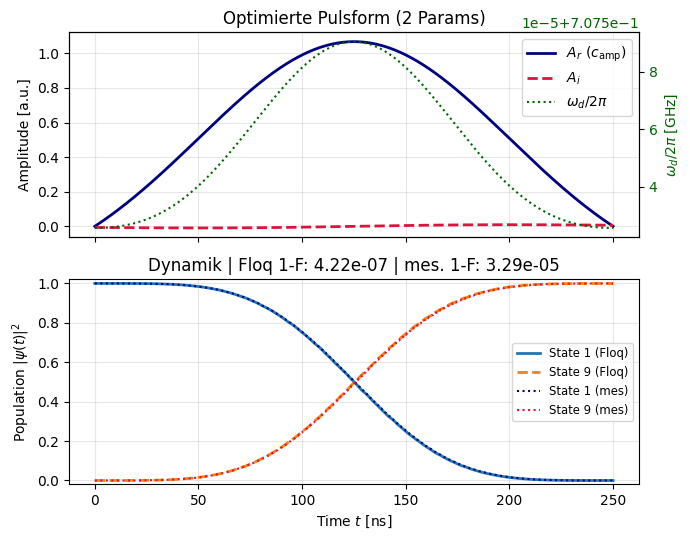

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sy

# 1. Setup & SymPy Auswertung
N_t, t_mes = 1001, np.linspace(0, tg, 1001)
t_sym, p_syms = sy.Symbol("t", real=True), [sy.Symbol(k, real=True) for k in param_ranges]

A_ex, wd_ex = fitted_pulse(t_sym, p_syms, tg=tg, sigma_ratio=sigma_ratio, pulse_type =pulse)
A_f, wd_f = sy.lambdify([t_sym] + p_syms, A_ex, ["numpy", "scipy"]), sy.lambdify([t_sym] + p_syms, wd_ex, ["numpy", "scipy"])

p_vals = tuple(best_p[k] for k in param_ranges)
A_t, wd_t = A_f(t_mes, *p_vals), wd_f(t_mes, *p_vals)
Ar, Ai = np.real(A_t), np.imag(A_t)

q_sig = lambda t, args=None: float(Ar[i := min(int(t / tg * 1000), 1000)] * np.cos(wd_t[i] * t) + Ai[i] * np.sin(wd_t[i] * t))

# 2. Mesolve-Dynamik
H = [s.H0, [s.V1, q_sig]]
res_keys = list(s.resonances.keys() if isinstance(s.resonances, dict) else dict(s.resonances).keys())
ia, ib = res_keys.index(s.state_a), res_keys.index(s.state_b)
amp_a = resonant_subspace_column_evolution(H, t_mes, ia, debug=False, s=s)
amp_b = resonant_subspace_column_evolution(H, t_mes, ib, debug=False, s=s)
infid_mes = 1.0 - 0.5 * (np.abs(amp_a[ib, -1])**2 + np.abs(amp_b[ia, -1])**2)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True)

# Pulsshapes
ax1.plot(t_mes, Ar, label=r"$A_r$ ($c_{\mathrm{amp}}$)", color="navy", lw=2)
ax1.plot(t_mes, Ai, label=r"$A_i$", color="crimson", lw=2, ls="--")
ax1_d = ax1.twinx()
ax1_d.plot(t_mes, wd_t / (2 * np.pi), label=r"$\omega_d / 2\pi$", color="darkgreen", lw=1.5, ls=":")
ax1_d.set_ylabel(r"$\omega_d / 2\pi$ [GHz]", color="darkgreen")
ax1_d.tick_params(axis="y", labelcolor="darkgreen")
ax1.set(ylabel="Amplitude [a.u.]", title="Optimierte Pulsform (2 Params)")
l1, l2 = ax1.get_legend_handles_labels()
l3, l4 = ax1_d.get_legend_handles_labels()
ax1.legend(l1 + l3, l2 + l4, loc="upper right")
ax1.grid(True, alpha=0.3)

# Dynamik
curves = [
    (tlist, np.abs(best_psi_t[s.state_a])**2, f"State {s.state_a} (Floq)", "tab:blue", "-", 2),
    (tlist, np.abs(best_psi_t[s.state_b])**2, f"State {s.state_b} (Floq)", "tab:orange", "--", 2),
    (t_mes, np.abs(amp_a[ia])**2, f"State {s.state_a} (mes)", "navy", ":", 1.5),
    (t_mes, np.abs(amp_a[ib])**2, f"State {s.state_b} (mes)", "crimson", ":", 1.5),
]
for x, y, lbl, col, ls, lw in curves:
    ax2.plot(x, y, label=lbl, color=col, ls=ls, lw=lw)

ax2.set(xlabel="Time $t$ [ns]", ylabel="Population $|\psi(t)|^2$", ylim=(-0.02, 1.02))
ax2.set_title(f"Dynamik | Floq 1-F: {best_infid:.2e} | mes. 1-F: {infid_mes:.2e}")
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True, fontsize="small", loc="center right")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle
import numpy as np
import sympy as sy

# 1. Parameter definieren
tg_val = tg
fit_dir = "operational_res/fit_data_gauss"

output_dir = "operational_res/final_forms"
os.makedirs(output_dir, exist_ok=True)

tg_int = int(round(tg_val))
filename = f"pulse_shape_sigma_{sigma_ratio:.1f}_tg_{tg_int}ns.pkl"
filepath = os.path.join(output_dir, filename)

# 2. Builder mit den konkreten tg- und sigma-Werten (greift auf operational_res/fit_data_gauss zu)
t_sym = sy.Symbol("t", real=True)
p_names = list(best_p.keys())
p_syms = [sy.Symbol(name, real=True) for name in p_names]

A_expr_sym, wd_expr_sym = fitted_pulse(t_sym, p_syms, tg=tg_val, sigma_ratio=sigma_ratio)

# Optimierte Parameter durch konkrete Best-Values ersetzen
param_substitutions = [(p_sym, best_p[name]) for p_sym, name in zip(p_syms, p_names)]

A_expr_opt = A_expr_sym.subs(param_substitutions)
wd_expr_opt = wd_expr_sym.subs(param_substitutions)

# 3. Fit-Parameter direkt aus operational_res/fit_data_gauss laden
popt_real, popt_imag, popt_freq, freq_model = load_fit_params(tg_val, sigma_ratio, fit_dir=fit_dir)

saved_data = {
    "metadata": {
        "sigma": sigma_ratio,
        "tg": tg_val,
        "best_infidelity": best_infid,
        "freq_model": str(freq_model),
        "fit_dir": fit_dir,
    },
    "best_parameters": best_p,
    "fit_parameters": {
        "popt_real": popt_real,
        "popt_imag": popt_imag,
        "popt_freq": popt_freq,
    },
    "sympy_expressions": {
        "A_t": A_expr_opt,
        "wd_t": wd_expr_opt,
        "t_symbol": t_sym,
    },
    "simulation_data": {
        "tlist": tlist,
        "best_psi_t": best_psi_t,
    }
}

# 4. Speichern via Pickle
with open(filepath, "wb") as f:
    pickle.dump(saved_data, f)

print(f"✅ Ergebnisse erfolgreich gespeichert unter:\n   {filepath}")
print(f"   Infidelity: {best_infid:.6e}")

FileNotFoundError: Keine Fit-Datei unter 'operational_res/fit_data_gauss/fit_params_gauss_tg_250ns_sigma_0.3.npz' gefunden.